# Individual Notebook

**Tianyi Zhu 386499** Team ShallowSeek (g67)  CS-552 Modern NLP, Final Individual Notebook


## My individual contribution

I experimented with the decoding temperature sweep of the runtime ablation:

1. Ran the vLLM runtime sweep over sampling temperature
   `T ∈ {0.0 (greedy), 0.5, 1.0, 1.5, 2.0}` on the
   Qwen3-8B (target) / Qwen3-0.6B-JSD (draft) pair.
2. Analyse how temperature affects wall-clock speedup, by deriving the per-token
   acceptance probability from first principles (`Σ min(p,q) = 1 − TV(p,q)`) and computing
   it from the real model logits, then validating it against the measured sweep.

**Result:** greedy decoding (`T=0`) with `γ=1` gives the best speedup (1.19×).
A higher temperature of `T=2.0` has a speedup (0.77×) worse than vanilla
decoding.

> **Reproducibility / self-containment.** The expensive sweep was run in advance on the RCP
> cluster. The metrics from the runs are summarised in this notebook with a copy
> archived at `notebooks/data/qwen3_8b_0p6b_jsd_runtime_sweep.csv`. Sections
> 7 and 8 loads the *public* models and dataset from Hugging Face and recomputes the mechanism
> on a handful of prompts in well under a minute on the 40 GB A100 launched by `submit.sh`.
> No `/scratch` paths are referenced anywhere.

## 1. Environment & dependencies

In [1]:
import os, subprocess, sys
if os.environ.get("FORCE_PIP") == "1":
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                               "pandas>=2.0", "matplotlib>=3.7"])
    except Exception as e:
        print("pip install skipped:", repr(e)[:160])
print("ok")

ok


In [2]:
import os, io, warnings, random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import display

warnings.filterwarnings("ignore")
random.seed(0); np.random.seed(0)

REPO = Path.cwd().resolve()
if REPO.name == "notebooks":
    REPO = REPO.parent
print("repo root:", REPO)

print("HF_HOME:", os.environ.get("HF_HOME", "<default ~/.cache/huggingface>"))

repo root: /scratch/cs552-repos/cs552-kdsd-youyang
HF_HOME: /scratch/hf_cache


In [3]:
import torch, transformers, datasets

print(f"torch {torch.__version__} | transformers {transformers.__version__} | "
      f"datasets {datasets.__version__} | pandas {pd.__version__} | matplotlib {matplotlib.__version__}")
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"CUDA available: {torch.cuda.is_available()} | device: {DEVICE}")
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0),
          f"({torch.cuda.get_device_properties(0).total_memory/1e9:.0f} GB)")

torch 2.8.0+cu128 | transformers 4.57.0 | datasets 4.8.5 | pandas 3.0.2 | matplotlib 3.10.9
CUDA available: True | device: cuda
GPU: NVIDIA A100-SXM4-40GB (42 GB)


## 2. Load models and dataset from Hugging Face

The runtime sweep used the exact pair below. Both are public on the Hub:

| role | model | size |
|------|-------|------|
| target | `Qwen/Qwen3-8B` | 8.2 B |
| draft  | `epfl-cs552-shallowseek/qwen3-06b-jsd-specdec` (our distilled JSD draft) | 0.6 B |

Loading both in bf16 needs ≈ 18 GB and fits on the 40 GB A100. If a GPU is not
available the heavy live sections (§7–8) are skipped automatically and every precomputed
figure (§3–6, §9–10) still renders.

In [4]:
from transformers import AutoModelForCausalLM, AutoTokenizer

TARGET_ID = "Qwen/Qwen3-8B"
DRAFT_ID  = "epfl-cs552-shallowseek/qwen3-06b-jsd-specdec"   # our distilled draft (public)

MODELS_OK = False
tokenizer = target = draft = None
if DEVICE == "cuda":
    try:
        tokenizer = AutoTokenizer.from_pretrained(DRAFT_ID)
        if tokenizer.pad_token_id is None:
            tokenizer.pad_token = tokenizer.eos_token
        target = AutoModelForCausalLM.from_pretrained(
            TARGET_ID, torch_dtype=torch.bfloat16, device_map=DEVICE).eval()
        draft = AutoModelForCausalLM.from_pretrained(
            DRAFT_ID, torch_dtype=torch.bfloat16, device_map=DEVICE).eval()
        np_t = sum(p.numel() for p in target.parameters())/1e9
        np_d = sum(p.numel() for p in draft.parameters())/1e9
        assert target.config.vocab_size == draft.config.vocab_size, "tokenizers must match for SD"
        print(f"target {TARGET_ID}: {np_t:.2f}B params")
        print(f"draft  {DRAFT_ID}: {np_d:.2f}B params")
        print(f"shared vocab size: {target.config.vocab_size}")
        MODELS_OK = True
    except Exception as e:
        print("Model load failed -> live sections will be skipped. Reason:", repr(e)[:200])
else:
    print("No GPU -> live sections will be skipped; precomputed analysis still runs.")

`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/5 [00:00<?, ?it/s]

target Qwen/Qwen3-8B: 8.19B params
draft  epfl-cs552-shallowseek/qwen3-06b-jsd-specdec: 0.60B params
shared vocab size: 151936


In [5]:
from datasets import load_dataset

DATA_OK = False
EVAL_PROMPTS = []
try:
    ds = load_dataset("HuggingFaceH4/ultrachat_200k", split="test_sft")
    EVAL_PROMPTS = [ds[i]["prompt"] for i in range(8)]
    DATA_OK = True
    print(f"UltraChat test_sft: {len(ds)} examples")
    print("example prompt:", EVAL_PROMPTS[0][:160], "...")
except Exception as e:
    print("Dataset load failed -> live sections will be skipped. Reason:", repr(e)[:200])

UltraChat test_sft: 23110 examples
example prompt: How does the author propose to fix the problem of science alienation in our educational system? What changes does she suggest should be made to science educatio ...


In [6]:
def chat_ids(prompt):
    msgs = [{"role": "user", "content": prompt}]
    try:                                  # Qwen3 supports the thinking toggle
        return tokenizer.apply_chat_template(
            msgs, add_generation_prompt=True, return_tensors="pt", enable_thinking=False)
    except TypeError:
        return tokenizer.apply_chat_template(
            msgs, add_generation_prompt=True, return_tensors="pt")

if MODELS_OK:
    ids = chat_ids("In one sentence, what is speculative decoding?").to(DEVICE)
    with torch.inference_mode():
        for name, m in [("target", target), ("draft", draft)]:
            out = m.generate(ids, max_new_tokens=40, do_sample=False,
                             pad_token_id=tokenizer.pad_token_id)
            txt = tokenizer.decode(out[0, ids.shape[1]:], skip_special_tokens=True)
            print(f"[{name}] {txt.strip()[:200]}")
else:
    print("skipped (models unavailable)")

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


[target] Speculative decoding is a technique used in natural language processing where a model generates text in a single forward pass by leveraging a pre-trained model to predict the next token, allowing for 


[draft] Speculative decoding is a method used in cryptography to reverse-engineer a message by assuming the original message was encrypted using a specific key and cipher, and then decoding it based on that a


## 3. The precomputed runtime sweep

Each row is a vLLM speculative-decoding run on 50 UltraChat prompts × 3 repeats, with the
distilled JSD draft and `top_p = 0.9`. Speedup is `T_vanilla / T_speculative`, where the
denominator is target-only autoregressive decoding under the same settings. `acceptance_rate`
is the fraction of drafted tokens the target accepts.

Grid: temperature `{0.0, 0.5, 1.0, 1.5, 2.0}` × `γ {1,2,4,6,8}` × max-new-tokens `{128,256,512}`
= 75 runs.

In [7]:
SWEEP_CSV = r"""
runtime_mode,runtime_temperature,runtime_top_p,gamma,max_new_tokens,speedup,acceptance_rate,avg_accepted_tokens,tokens_per_second,sd_time_s,vanilla_time_s,n_prompts,n_repeats
greedy,0.0,0.9,1,128,1.1844171881813688,0.7700290211942661,0.7700290211942661,625.6537083507654,10.229300832996765,12.115759729679363,50,3
sampling,0.5,0.9,1,128,1.1662033482060905,0.7765422292824994,0.7765422292824994,599.9094275676688,10.668277086340822,12.441380457680983,50,3
sampling,1.0,0.9,1,128,1.173985406039138,0.7602554010321001,0.7602554010321001,604.4907747354149,10.587423774665998,12.429480999009684,50,3
sampling,1.5,0.9,1,128,1.15290181357218,0.7389915385943706,0.7389915385943706,592.834212385782,10.795598273999834,12.446264828691104,50,3
sampling,2.0,0.9,1,128,0.8124617208542547,0.47823511992893103,0.47823511992893103,396.1977846416208,16.04249252869825,13.033911086657705,50,3
greedy,0.0,0.9,2,128,0.9978358922425541,0.667957461565137,1.335914923130274,527.1704693793012,12.140285489692664,12.114012603686811,50,3
sampling,0.5,0.9,2,128,1.0049673854877033,0.6735393193169938,1.3470786386339877,516.7590431703094,12.384882441023365,12.446402926327815,50,3
sampling,1.0,0.9,2,128,0.7942548024442038,0.6620936130966105,1.324187226193221,408.7139533326065,15.658873272652272,12.437135297669252,50,3
sampling,1.5,0.9,2,128,0.9810093929919234,0.6370249238750423,1.2740498477500846,503.78489241828754,12.70383470468611,12.462581172313852,50,3
sampling,2.0,0.9,2,128,0.595653655875972,0.35775382773073305,0.7155076554614661,290.82279002861526,21.89993431867333,13.044775940361433,50,3
greedy,0.0,0.9,4,128,0.6363143513308517,0.5317600862334463,2.127040344933785,335.96026103852387,19.049872089681838,12.121707001681594,50,3
sampling,0.5,0.9,4,128,0.6430832410751084,0.5299938395194825,2.11997535807793,330.14164317354715,19.385618665003374,12.466566481336486,50,3
sampling,1.0,0.9,4,128,0.6130842908160596,0.5015956657265845,2.006382662906338,315.1865806972484,20.305433010003373,12.448941996650925,50,3
sampling,1.5,0.9,4,128,0.6208622566749847,0.48631134410950927,1.945245376438037,318.7195905246821,20.080347083353747,12.467129604987955,50,3
sampling,2.0,0.9,4,128,0.3015661043902918,0.23932644507261916,0.9573057802904766,147.0494624082004,43.27115445234813,13.049113480665255,50,3
greedy,0.0,0.9,6,128,0.4476698883072564,0.4303574572988202,2.5821447437929215,236.35222106029266,27.07823083400338,12.1221085730164,50,3
sampling,0.5,0.9,6,128,0.46177492922079116,0.4165373786128828,2.499224271677297,237.21583560584716,26.97964907635469,12.45852554263547,50,3
sampling,1.0,0.9,6,128,0.4495675062409816,0.4080401155872854,2.4482406935237124,231.33176383960358,27.665893752651755,12.4376868623076,50,3
sampling,1.5,0.9,6,128,0.4477190205788219,0.3704999734902709,2.2229998409416254,229.99558627838098,27.82662095199339,12.458507478644606,50,3
sampling,2.0,0.9,6,128,0.21035357926342851,0.16334772088156432,0.9800863252893859,103.22289649602779,62.0017478413453,13.042289579015536,50,3
greedy,0.0,0.9,8,128,0.37352665061849394,0.3610156548300878,2.8881252386407024,197.37437272382616,32.42568886567218,12.11185895599192,50,3
sampling,0.5,0.9,8,128,0.3775056123548056,0.34194612424409015,2.7355689939527212,194.07959202399473,32.97616165232224,12.448686097670967,50,3
sampling,1.0,0.9,8,128,0.3639891764775198,0.31600710079667477,2.528056806373398,187.26109369920147,34.17688038434911,12.440014545669934,50,3
sampling,1.5,0.9,8,128,0.35038360140922786,0.300852797849101,2.406822382792808,179.97560106485923,35.56037575167526,12.459772523337355,50,3
sampling,2.0,0.9,8,128,0.15699684690529445,0.127739898989899,1.021919191919192,76.3344093413983,83.04249754064949,13.037410273022639,50,3
greedy,0.0,0.9,1,256,1.1936593451279154,0.7215962441314554,0.7215962441314554,634.1975885880727,20.182984341673244,24.091607872008655,50,3
sampling,0.5,0.9,1,256,1.1455835447170595,0.7210779924097054,0.7210779924097054,592.0415805075496,21.62010308300766,24.76763432698014,50,3
sampling,1.0,0.9,1,256,1.1560925347714506,0.7072014893797072,0.7072014893797072,597.8053921403215,21.411650293370865,24.753849061302997,50,3
sampling,1.5,0.9,1,256,1.1150510906145121,0.6741764168948635,0.6741764168948635,575.299064122367,22.249297449365258,24.809103386321414,50,3
sampling,2.0,0.9,1,256,0.7731782932761201,0.33206470028544244,0.33206470028544244,367.9824404838616,33.96901217233002,26.264102855677873,50,3
greedy,0.0,0.9,2,256,1.0113953651075527,0.6145781603487281,1.2291563206974563,537.199230022303,23.827286572001565,24.098807202011812,50,3
sampling,0.5,0.9,2,256,1.0127194863706157,0.614614366103939,1.229228732207878,523.4114160841629,24.454949981338967,24.766004384320695,50,3
sampling,1.0,0.9,2,256,1.0068717480699172,0.5977233210171702,1.1954466420343404,521.1042270631478,24.563224274994962,24.732016563997604,50,3
sampling,1.5,0.9,2,256,0.937185240153519,0.5542769166536193,1.1085538333072387,483.7356385578526,26.46073387968742,24.79860923567321,50,3
sampling,2.0,0.9,2,256,0.5657231046961364,0.23308730806320005,0.4661746161264001,269.61305357266184,46.43321172365298,26.268340697318006,50,3
greedy,0.0,0.9,4,256,0.6345528106196885,0.46649192405780676,1.865967696231227,337.2460763898735,37.95448159700027,24.084122972989764,50,3
sampling,0.5,0.9,4,256,0.6342258315027421,0.458765233225942,1.835060932903768,327.6207180826669,39.069568233991355,24.77892939965629,50,3
sampling,1.0,0.9,4,256,0.5889439991852603,0.4210822998872604,1.6843291995490417,304.5398394566998,42.03062569033742,24.753684782326065,50,3
sampling,1.5,0.9,4,256,0.5596202364139915,0.39151392148157543,1.5660556859263017,288.4972114017824,44.367846530668125,24.82914476467219,50,3
sampling,2.0,0.9,4,256,0.29466537868877896,0.1407014043735086,0.5628056174940343,141.79480977653535,89.10763391066575,26.256934690347407,50,3
greedy,0.0,0.9,6,256,0.45520404245753626,0.3645063184940486,2.1870379109642912,241.85296853865398,52.92471734931072,24.091545283328742,50,3
sampling,0.5,0.9,6,256,0.43740464519653394,0.35141871165644173,2.1085122699386503,226.0053331872212,56.60928359332805,24.761163604969624,50,3
sampling,1.0,0.9,6,256,0.4346949671408115,0.33027916789323913,1.9816750073594347,224.9195078562197,56.90924776601605,24.738163587656647,50,3
sampling,1.5,0.9,6,256,0.4041533123488518,0.2924400027194235,1.754640016316541,208.55542920577895,61.37457101330316,24.804736169016298,50,3
sampling,2.0,0.9,6,256,0.1957662921732907,0.09494171112428373,0.5696502667457024,93.93940039339337,134.18224884567704,26.268361331992008,50,3
greedy,0.0,0.9,8,256,0.31673747713510886,0.2942105915399868,2.3536847323198944,168.02579762113805,76.17877838533605,24.1286740770059,50,3
sampling,0.5,0.9,8,256,0.3683577335254515,0.28143796615606703,2.2515037292485363,190.2150163056066,67.29226876302467,24.787627605333302,50,3
sampling,1.0,0.9,8,256,0.3420226534619635,0.2580020406620815,2.064016325296652,176.87392517134936,72.36793092933173,24.751471762002137,50,3
sampling,1.5,0.9,8,256,0.30737486726968827,0.23174642328564382,1.8539713862851506,158.38846319348576,80.81396676198347,24.84018230700167,50,3
sampling,2.0,0.9,8,256,0.14969767651086827,0.07025515210991168,0.5620412168792934,71.8432285115758,175.5349844553275,26.277179319333907,50,3
greedy,0.0,0.9,1,512,1.1861996019875323,0.7037037037037037,0.7037037037037037,610.1997299247466,40.66865123499883,48.24113790832538,50,3
sampling,0.5,0.9,1,512,1.1402927631609832,0.6998665403822972,0.6998665403822972,574.7035519212455,43.570289267033026,49.682885540028416,50,3
sampling,1.0,0.9,1,512,1.138040281449829,0.6850517687661778,0.6850517687661778,564.5941510212648,43.594146265027426,49.61189448501682,50,3
sampling,1.5,0.9,1,512,1.059551815496894,0.633371547681084,0.633371547681084,523.5950681269118,47.07454577098057,49.87792043533409,50,3
sampling,2.0,0.9,1,512,0.7538864664993237,0.2064240790655885,0.2064240790655885,340.13047029259724,69.94080824201228,52.72742878967741,50,3
greedy,0.0,0.9,2,512,1.030843485032353,0.5910474435229399,1.1820948870458798,527.5780267941476,46.75327391833222,48.195307822645795,50,3
sampling,0.5,0.9,2,512,1.016200676184081,0.5930908486962299,1.1861816973924597,512.5855964593086,48.85232861198407,49.64376936866514,50,3
sampling,1.0,0.9,2,512,0.962476590390121,0.5704682429299953,1.1409364858599906,480.1379137012038,51.50395187368849,49.571347991004586,50,3
sampling,1.5,0.9,2,512,0.9338111396112226,0.5209015554645927,1.0418031109291854,471.6117741414102,53.42529890368072,49.889139253316294,50,3
sampling,2.0,0.9,2,512,0.54532923918387,0.13416441390092174,0.2683288278018435,255.71795399015627,96.59861427231226,52.67804882733617,50,3
greedy,0.0,0.9,4,512,0.6143556281574554,0.44164547573638485,1.7665819029455394,314.51638009206755,78.50783476768993,48.231730143985864,50,3
sampling,0.5,0.9,4,512,0.6275497017438818,0.4360776323514176,1.7443105294056704,317.52457911625777,79.16552498065478,49.68030159000773,50,3
sampling,1.0,0.9,4,512,0.5881801816004063,0.40190112197362377,1.607604487894495,297.8153138551957,84.32407210668316,49.59774804499466,50,3
sampling,1.5,0.9,4,512,0.5468572082874357,0.3568297079310766,1.4273188317243064,275.1011432655102,91.22462997465239,49.88684647499273,50,3
sampling,2.0,0.9,4,512,0.29156013371723155,0.08905939904599422,0.3562375961839769,137.3925474302439,180.72304840702176,52.69163615933697,50,3
greedy,0.0,0.9,6,512,0.44688962620338146,0.3358295444414728,2.014977266648837,229.9467933803298,107.91626895599377,48.226661095007636,50,3
sampling,0.5,0.9,6,512,0.4433875482947867,0.3321804321804322,1.993082593082593,222.5778300736272,111.94735788266796,49.63606454967521,50,3
sampling,1.0,0.9,6,512,0.4322062452745843,0.3112132441990021,1.8672794651940126,217.62714232376925,114.75590651668608,49.59821947865809,50,3
sampling,1.5,0.9,6,512,0.3718183158931118,0.26227682174797406,1.5736609304878442,187.78296415232788,134.09629629434008,49.85945905566526,50,3
sampling,2.0,0.9,6,512,0.19413614675518998,0.05955974047098372,0.3573584428259023,87.45178570216966,271.7040002009987,52.74756765699325,50,3
greedy,0.0,0.9,8,512,0.3538317300094087,0.2719600081201786,2.175680064961429,180.95538700518927,136.29326215799665,48.22488073798983,50,3
sampling,0.5,0.9,8,512,0.3517178286451958,0.26412258422953294,2.1129806738362635,174.98387179926152,141.3558846633338,49.7173848200085,50,3
sampling,1.0,0.9,8,512,0.330849861353826,0.23798782276995306,1.9039025821596245,167.18444426387077,150.00797538566016,49.6301178583138,50,3
sampling,1.5,0.9,8,512,0.2839634155385374,0.2048326359832636,1.6386610878661088,141.48844159920728,175.632721083976,49.87326735933311,50,3
sampling,2.0,0.9,8,512,0.14615803169538533,0.04020947947524334,0.3216758358019467,68.64508135450737,360.57936725534574,52.70157058800881,50,3
"""


sweep = pd.read_csv(io.StringIO(SWEEP_CSV))
sweep["temperature"] = sweep["runtime_temperature"]
print("sweep shape:", sweep.shape)
print("temperatures:", sorted(sweep.temperature.unique()))
print("gammas      :", sorted(sweep.gamma.unique()))
print("max_new     :", sorted(sweep.max_new_tokens.unique()))

# Headline slice used throughout: gamma=1, max_new_tokens=256.
head = (sweep[(sweep.gamma == 1) & (sweep.max_new_tokens == 256)]
        .sort_values("temperature")
        [["temperature", "acceptance_rate", "avg_accepted_tokens",
          "tokens_per_second", "speedup"]]
        .round(4).reset_index(drop=True))
print("\nHeadline slice (gamma=1, max_new=256):")
display(head)

sweep shape: (75, 14)
temperatures: [np.float64(0.0), np.float64(0.5), np.float64(1.0), np.float64(1.5), np.float64(2.0)]
gammas      : [np.int64(1), np.int64(2), np.int64(4), np.int64(6), np.int64(8)]
max_new     : [np.int64(128), np.int64(256), np.int64(512)]

Headline slice (gamma=1, max_new=256):


,temperature,acceptance_rate,avg_accepted_tokens,tokens_per_second,speedup
0,0.0,0.7216,0.7216,634.1976,1.1937
1,0.5,0.7211,0.7211,592.0416,1.1456
2,1.0,0.7072,0.7072,597.8054,1.1561
3,1.5,0.6742,0.6742,575.2991,1.1151
4,2.0,0.3321,0.3321,367.9824,0.7732


## 4. Temperature × γ speedup heatmap

The interaction surface for `max_new_tokens=256`. Cells `> 1.0` (speculative decoding actually
faster than vanilla) are the win region; everything else is a net loss.

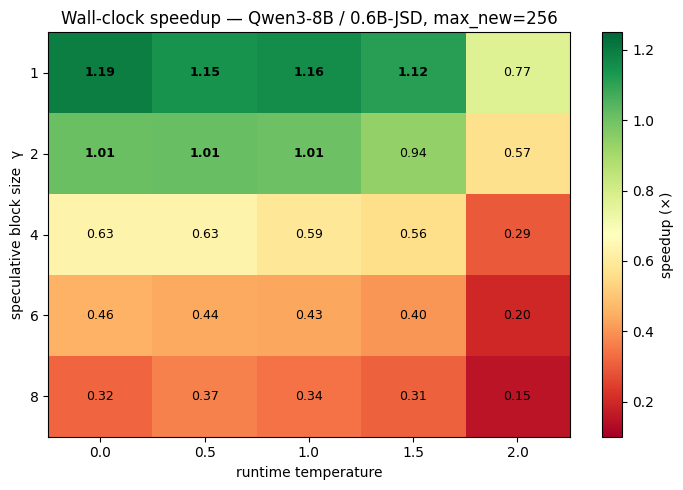

Win region (speedup > 1.0): only the smallest blocks (γ ≤ 2) at low temperature.


In [8]:
piv = (sweep[sweep.max_new_tokens == 256]
       .pivot(index="gamma", columns="temperature", values="speedup")
       .sort_index())

fig, ax = plt.subplots(figsize=(7.2, 5.0))
im = ax.imshow(piv.values, cmap="RdYlGn", vmin=0.1, vmax=1.25, aspect="auto")
ax.set_xticks(range(len(piv.columns))); ax.set_xticklabels(piv.columns)
ax.set_yticks(range(len(piv.index)));   ax.set_yticklabels(piv.index)
ax.set_xlabel("runtime temperature"); ax.set_ylabel("speculative block size  γ")
ax.set_title("Wall-clock speedup — Qwen3-8B / 0.6B-JSD, max_new=256")
for i in range(piv.shape[0]):
    for j in range(piv.shape[1]):
        v = piv.values[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                color="black", fontsize=9,
                fontweight="bold" if v >= 1.0 else "normal")
cbar = fig.colorbar(im, ax=ax); cbar.set_label("speedup (×)")
fig.tight_layout(); plt.show()

print("Win region (speedup > 1.0): only the smallest blocks (γ ≤ 2) at low temperature.")

## 5. Speedup vs. temperature at γ=1

Fix `γ=1` and read off temperature directly. The three curves are the three generation
lengths. Greedy (`T=0`) is best at every length; the drop is gentle up to `T=1.5` and then
falls off a cliff at `T=2.0`, crossing below the break-even line.

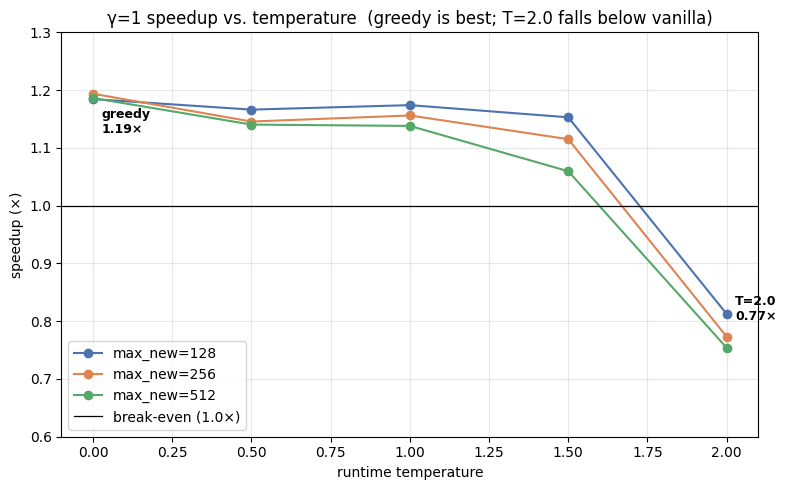

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
colors = {128: "#4C72B0", 256: "#DD8452", 512: "#55A868"}
for mnt in [128, 256, 512]:
    d = sweep[(sweep.gamma == 1) & (sweep.max_new_tokens == mnt)].sort_values("temperature")
    ax.plot(d.temperature, d.speedup, "o-", color=colors[mnt], label=f"max_new={mnt}")

ax.axhline(1.0, color="black", lw=0.9, ls="-", label="break-even (1.0×)")
# annotate the two endpoints the report quotes (max_new=256)
d256 = sweep[(sweep.gamma == 1) & (sweep.max_new_tokens == 256)].sort_values("temperature")
for T, msg in [(0.0, "greedy\n1.19×"), (2.0, "T=2.0\n0.77×")]:
    y = float(d256[d256.temperature == T].speedup.iloc[0])
    ax.annotate(msg, (T, y), textcoords="offset points", xytext=(6, -28 if T == 0 else 12),
                fontsize=9, fontweight="bold")
ax.set_xlabel("runtime temperature"); ax.set_ylabel("speedup (×)")
ax.set_title("γ=1 speedup vs. temperature  (greedy is best; T=2.0 falls below vanilla)")
ax.set_ylim(0.6, 1.3); ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout(); plt.show()

## 6. Acceptance rate vs. temperature

Speedup tracks acceptance. As temperature rises, the draft and target distributions both
flatten, so the target tends to reject more of the draft's proposals. Acceptance is highest at
low temperature, roughly flat up to `T≈1.5` (the small wiggles there are within run-to-run
noise), and then drops sharply. At `γ=1` the per-step token yield is `1 + acceptance`, so
collapsing acceptance directly collapses speedup.

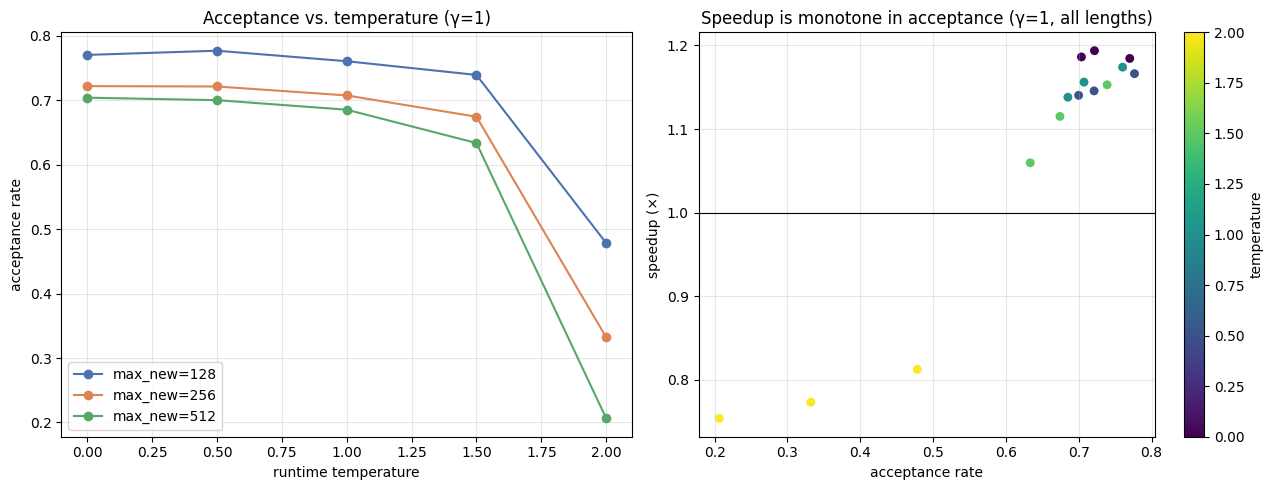

Acceptance (γ=1, max_new=256): T=0.0: 0.722, T=0.5: 0.721, T=1.0: 0.707, T=1.5: 0.674, T=2.0: 0.332


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
for mnt in [128, 256, 512]:
    d = sweep[(sweep.gamma == 1) & (sweep.max_new_tokens == mnt)].sort_values("temperature")
    ax.plot(d.temperature, d.acceptance_rate, "o-", color=colors[mnt], label=f"max_new={mnt}")
ax.set_xlabel("runtime temperature"); ax.set_ylabel("acceptance rate")
ax.set_title("Acceptance vs. temperature (γ=1)")
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
d = sweep[(sweep.gamma == 1)]
sc = ax.scatter(d.acceptance_rate, d.speedup, c=d.temperature, cmap="viridis", s=55,
                edgecolor="white")
ax.axhline(1.0, color="black", lw=0.8)
ax.set_xlabel("acceptance rate"); ax.set_ylabel("speedup (×)")
ax.set_title("Speedup is monotone in acceptance (γ=1, all lengths)")
fig.colorbar(sc, ax=ax, label="temperature"); ax.grid(alpha=0.3)
fig.tight_layout(); plt.show()

print("Acceptance (γ=1, max_new=256): "
      + ", ".join(f"T={t}: {a:.3f}" for t, a in
                  zip(d256.temperature, d256.acceptance_rate)))

## 7. Why temperature hurts

Speculative decoding accepts a drafted token `x` (drawn from draft distribution `q`) with
probability `min(1, p(x)/q(x))`, where `p` is the target distribution. Averaging over `x ~ q`,
the expected single-token acceptance is

$$\mathbb{E}_{x\sim q}\!\left[\min\!\Big(1,\tfrac{p(x)}{q(x)}\Big)\right]=\sum_x \min\big(p(x),q(x)\big)=1-\mathrm{TV}(p,q).$$

Both `p` and `q` are temperature-and-`top_p`-scaled (`_proposal_dist` in our
`kdsd.sd.instrument`). So temperature enters acceptance only through how much it flattens
the two distributions. I recompute this quantity from the real logits of the loaded models,
teacher-forced along the target's own greedy trajectory, and compare it to the measured
`γ=1` acceptance from the sweep.

In [11]:
import torch.nn.functional as F

def proposal_dist_batch(logits, temperature, top_p=0.9):

    logits = logits.float()
    if temperature <= 0:
        out = torch.zeros_like(logits)
        out.scatter_(1, logits.argmax(-1, keepdim=True), 1.0)
        return out
    scaled = logits / temperature
    if 0.0 < top_p < 1.0:
        sl, si = torch.sort(scaled, descending=True, dim=-1)
        probs = F.softmax(sl, dim=-1)
        keep = probs.cumsum(-1) <= top_p
        keep[:, 0] = True
        sl = sl.masked_fill(~keep, float("-inf"))
        scaled = torch.full_like(scaled, float("-inf")).scatter_(1, si, sl)
    return F.softmax(scaled, dim=-1)

def entropy(p):
    return -(p.clamp_min(1e-12).log() * p).sum(-1)

TEMPS = [0.0, 0.5, 1.0, 1.5, 2.0]
N_PROMPTS, GEN = 6, 48
live = None

if MODELS_OK and DATA_OK:
    acc = {T: 0.0 for T in TEMPS}; ent_t = {T: 0.0 for T in TEMPS}; ent_d = {T: 0.0 for T in TEMPS}
    npos = 0
    for prompt in EVAL_PROMPTS[:N_PROMPTS]:
        ids = chat_ids(prompt).to(DEVICE); L = ids.shape[1]
        with torch.inference_mode():
            seq = target.generate(ids, max_new_tokens=GEN, do_sample=False,
                                  pad_token_id=tokenizer.pad_token_id)
            tl = target(seq).logits[0]
            dl = draft(seq).logits[0]
        G = seq.shape[1] - L
        if G <= 0:
            continue
        ts, dsl = tl[L-1:L-1+G], dl[L-1:L-1+G]
        npos += G
        for T in TEMPS:
            p, q = proposal_dist_batch(ts, T), proposal_dist_batch(dsl, T)
            acc[T]   += torch.minimum(p, q).sum(-1).sum().item()
            ent_t[T] += entropy(p).sum().item()
            ent_d[T] += entropy(q).sum().item()
    if npos > 0:
        live = pd.DataFrame({
            "temperature": TEMPS,
            "predicted_acc": [acc[T]/npos for T in TEMPS],
            "entropy_target": [ent_t[T]/npos for T in TEMPS],
            "entropy_draft":  [ent_d[T]/npos for T in TEMPS],
        })
        print(f"computed over {npos} token positions ({N_PROMPTS} prompts × ≤{GEN} tokens)")
        display(live.round(4))
    else:
        print("no continuation tokens generated -> live curve skipped.")
else:
    print("skipped (models/dataset unavailable) — see the precomputed sweep for the measured curve.")

computed over 288 token positions (6 prompts × ≤48 tokens)


,temperature,predicted_acc,entropy_target,entropy_draft
0,0.0,0.7083,0.0000,0.0000
1,0.5,0.7172,0.0379,0.0825
2,1.0,0.7120,0.2097,0.3723
3,1.5,0.6923,0.5438,1.0704
4,2.0,0.6332,1.2079,2.7256


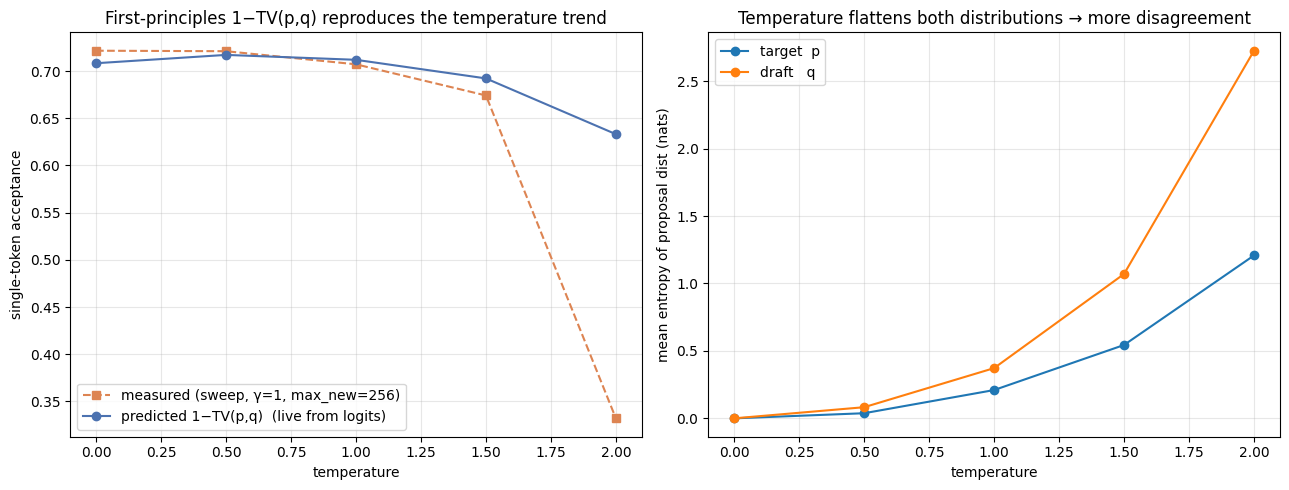

Mechanism: higher T raises the entropy of p and q, the draft proposes lower-probability
tokens, agreement (1−TV) falls, and acceptance, hence speedup, collapses.


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(d256.temperature, d256.acceptance_rate, "s--", color="#DD8452",
        label="measured (sweep, γ=1, max_new=256)")
if live is not None:
    ax.plot(live.temperature, live.predicted_acc, "o-", color="#4C72B0",
            label="predicted 1−TV(p,q)  (live from logits)")
ax.set_xlabel("temperature"); ax.set_ylabel("single-token acceptance")
ax.set_title("First-principles 1−TV(p,q) reproduces the temperature trend")
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
if live is not None:
    ax.plot(live.temperature, live.entropy_target, "o-", label="target  p")
    ax.plot(live.temperature, live.entropy_draft,  "o-", label="draft   q")
    ax.set_xlabel("temperature"); ax.set_ylabel("mean entropy of proposal dist (nats)")
    ax.set_title("Temperature flattens both distributions → more disagreement")
    ax.legend(); ax.grid(alpha=0.3)
else:
    ax.text(0.5, 0.5, "live entropy unavailable\n(models not loaded)",
            ha="center", va="center"); ax.axis("off")
fig.tight_layout(); plt.show()

print("Mechanism: higher T raises the entropy of p and q, the draft proposes lower-probability\n"
      "tokens, agreement (1−TV) falls, and acceptance, hence speedup, collapses.")

## 8. Token-level qualitative example

For one prompt and the target's greedy continuation, I show that
per-token expected acceptance `Σ min(p,q) = 1−TV(p,q)` at greedy, `T=1`, and `T=2` as an example. Tokens lose acceptance as temperature increases, where the distributions are flattened.

Note that this is a relatively easy prompt, so the
per-token erosion at `T=2` is visible but mild here. The representative magnitude is the 288-position
average in §7, and the population effect is the full sweep in §5–6.

,token,E[accept] greedy,E[accept] T=1.0,E[accept] T=2.0
0,'The',1.0,1.0,0.912
1,' tolerant',1.0,1.0,0.279
2,' rice',1.0,1.0,1.000
3,' cultiv',1.0,1.0,1.000
4,'ar',1.0,1.0,1.000
5,' **',1.0,1.0,0.777
6,'K',1.0,1.0,1.000
7,'oshi',1.0,1.0,1.000
8,'h',1.0,1.0,1.000
9,'ik',1.0,1.0,1.000


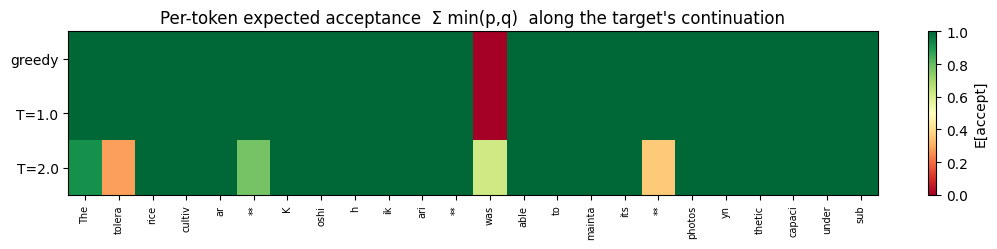

mean E[accept]: greedy=0.958, T=1.0=0.958, T=2.0=0.914


In [13]:
def token_accept(target_logits, draft_logits, T, top_p=0.9):
    p = proposal_dist_batch(target_logits, T, top_p)
    q = proposal_dist_batch(draft_logits,  T, top_p)
    return torch.minimum(p, q).sum(-1)

if MODELS_OK and DATA_OK:
    ids = chat_ids(EVAL_PROMPTS[1]).to(DEVICE); L = ids.shape[1]
    with torch.inference_mode():
        seq = target.generate(ids, max_new_tokens=24, do_sample=False,
                              pad_token_id=tokenizer.pad_token_id)
        ts = target(seq).logits[0][L-1:-1]
        dsl = draft(seq).logits[0][L-1:-1]
    toks = seq[0, L:]
    a0 = token_accept(ts, dsl, 0.0)
    a1 = token_accept(ts, dsl, 1.0)
    a2 = token_accept(ts, dsl, 2.0)
    qual = pd.DataFrame({
        "token": [repr(tokenizer.decode([int(t)])) for t in toks],
        "E[accept] greedy": [round(float(v), 3) for v in a0],
        "E[accept] T=1.0":  [round(float(v), 3) for v in a1],
        "E[accept] T=2.0":  [round(float(v), 3) for v in a2],
    })
    display(qual)

    fig, ax = plt.subplots(figsize=(11, 2.6))
    M = np.vstack([a0.cpu().numpy(), a1.cpu().numpy(), a2.cpu().numpy()])
    im = ax.imshow(M, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
    ax.set_yticks(range(3)); ax.set_yticklabels(["greedy", "T=1.0", "T=2.0"])
    ax.set_xticks(range(M.shape[1]))
    ax.set_xticklabels([tokenizer.decode([int(t)]).strip()[:6] for t in toks],
                       rotation=90, fontsize=7)
    ax.set_title("Per-token expected acceptance  Σ min(p,q)  along the target's continuation")
    fig.colorbar(im, ax=ax, label="E[accept]")
    fig.tight_layout(); plt.show()
    print(f"mean E[accept]: greedy={a0.mean():.3f}, T=1.0={a1.mean():.3f}, T=2.0={a2.mean():.3f}")
else:
    print("skipped (models/dataset unavailable)")

## 9. Attributing speedup: token-yield vs. system overhead

Why does acceptance `0.72` only buy `1.19×` rather than `1.72×`? At `γ=1` each speculative step
produces `1 + acceptance` tokens (an accepted token *plus* the target's free bonus token, or a
single resampled token on rejection) for roughly a fixed per-step cost (one draft forward + one
target verification + scheduling). So we expect

$$\text{speedup} \approx k\,(1+\text{acceptance}),\qquad k=\frac{T_{\text{target}}}{T_{\text{target}}+T_{\text{draft}}+\text{overhead}}.$$

Fitting `k` over the well-behaved runs (`T ≤ 1.5`) quantifies how much of the raw token-yield
the system actually keeps.

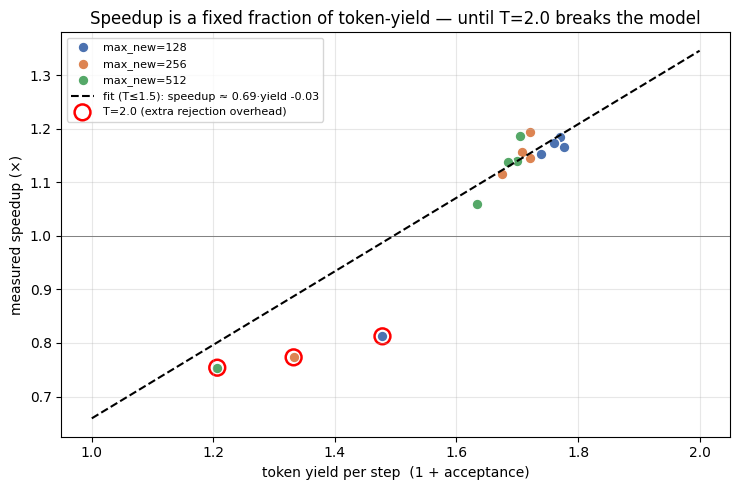

Retained fraction k ≈ 0.69: only 69% of the token-yield converts to wall-clock speedup.
Even a perfect draft (yield=2.0) would cap near 1.35× at γ=1 with this 8B/0.6B pair.
T=2.0 points sit below the line: heavy rejection adds resample + cache-crop overhead
that the linear yield model does not capture.


In [14]:
g1 = sweep[sweep.gamma == 1].copy()
g1["yield"] = 1.0 + g1["acceptance_rate"]
fit = g1[g1.temperature <= 1.5]
k, b = np.polyfit(fit["yield"], fit["speedup"], 1)

fig, ax = plt.subplots(figsize=(7.5, 5))
for mnt in [128, 256, 512]:
    d = g1[g1.max_new_tokens == mnt]
    ax.scatter(d["yield"], d["speedup"], s=60, color=colors[mnt], edgecolor="white",
               label=f"max_new={mnt}")
xs = np.linspace(1.0, 2.0, 50)
ax.plot(xs, k*xs + b, "k--", label=f"fit (T≤1.5): speedup ≈ {k:.2f}·yield {b:+.2f}")
ax.axhline(1.0, color="grey", lw=0.7)
d2 = g1[g1.temperature == 2.0]
ax.scatter(d2["yield"], d2["speedup"], s=130, facecolor="none", edgecolor="red", lw=1.8,
           label="T=2.0 (extra rejection overhead)")
ax.set_xlabel("token yield per step  (1 + acceptance)")
ax.set_ylabel("measured speedup (×)")
ax.set_title("Speedup is a fixed fraction of token-yield — until T=2.0 breaks the model")
ax.legend(fontsize=8); ax.grid(alpha=0.3)
fig.tight_layout(); plt.show()

print(f"Retained fraction k ≈ {k:.2f}: only {k*100:.0f}% of the token-yield converts to "
      f"wall-clock speedup.\nEven a perfect draft (yield=2.0) would cap near "
      f"{k*2+b:.2f}× at γ=1 with this 8B/0.6B pair.")
print("T=2.0 points sit below the line: heavy rejection adds resample + cache-crop overhead\n"
      "that the linear yield model does not capture.")

## 10. Generation length × temperature interaction

Does generating longer affect the overhead? Only mildly. At low temperature speedup is nearly
length-independent (greedy peaks at `max_new=256`, 1.19×). At `T=2.0` longer generations make
things worse, because each extra step compounds the low acceptance.

Speedup by temperature × generation length (γ=1):


max_new_tokens,128,256,512
temperature,,,
0.0,1.184,1.194,1.186
0.5,1.166,1.146,1.140
1.0,1.174,1.156,1.138
1.5,1.153,1.115,1.060
2.0,0.812,0.773,0.754


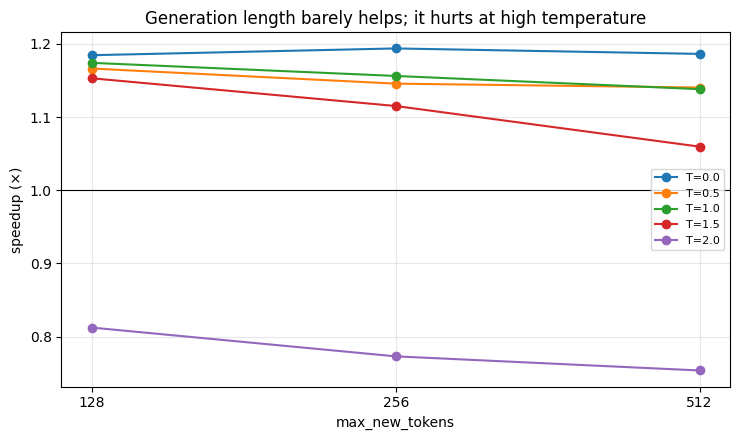

In [15]:
tab = (sweep[sweep.gamma == 1]
       .pivot(index="temperature", columns="max_new_tokens", values="speedup")
       .round(3))
print("Speedup by temperature × generation length (γ=1):")
display(tab)

fig, ax = plt.subplots(figsize=(7.5, 4.5))
for T in TEMPS:
    d = sweep[(sweep.gamma == 1) & (sweep.temperature == T)].sort_values("max_new_tokens")
    ax.plot(d.max_new_tokens, d.speedup, "o-", label=f"T={T}")
ax.axhline(1.0, color="black", lw=0.8)
ax.set_xscale("log", base=2); ax.set_xticks([128, 256, 512]); ax.set_xticklabels([128, 256, 512])
ax.set_xlabel("max_new_tokens"); ax.set_ylabel("speedup (×)")
ax.set_title("Generation length barely helps; it hurts at high temperature")
ax.legend(fontsize=8); ax.grid(alpha=0.3)
fig.tight_layout(); plt.show()

## 11. Discussion


Greedy decoding is the speculative-decoding sweet spot. At `γ=1`, `T=0` is fastest at
  every generation length (up to 1.19×). §7 shows the
  acceptance integral `1−TV(p,q)` is maximised when both distributions are sharpest, i.e. at
  `T→0`, because exact agreement is what speculative decoding rewards.

There is a cliff, not a slope. Speedup is roughly flat for `T ≤ 1.5` and then collapses at
  `T = 2.0` (1.19× → 0.77×, below vanilla). The §9 attribution shows two compounding causes:
  (i) acceptance/token-yield drops as the distributions flatten, and (ii) the resulting wave of
  rejections adds resample + KV-cache-crop overhead that pushes the `T=2.0` points below even
  the linear yield model.

Improving the draft (KD objective, data) lifts acceptance, but the runtime knobs (`temperature`, `γ`, length)
  decide how much of that becomes real speedup. The retained-fraction `k ≈ 0.69` (§9) is a
  system property of the 8B/0.6B pair. With this draft cost and verification overhead, even a
  perfect draft caps near ~1.35× at `γ=1`. 

Low temperature only wins at small `γ`. Large
  `γ` is already a loss at `T=0` and high `T` makes it catastrophic, because wasted draft work
  after the first rejection grows with `γ`.

A technicality is that lowering temperature for speed is not free in
general. Speculative decoding preserves the target's sampling distribution at the
chosen temperature. So `T=0` yields greedy outputs, not temperature-1 samples. The right
reading is "for a target you would already run greedily/low-temperature, speculative decoding is
strongly beneficial; for high-temperature creative sampling, a draft this size does not pay off."

**Limitations** `top_p` is fixed at
0.9. The live `1−TV` estimate in §7 is teacher-forced along the target's greedy trajectory
(it isolates the accept/reject decision while holding the realized tokens fixed), so it tracks
the trend rather than reproducing the sweep exactly.

## 12. Conclusion

Practical speculative-decoding acceleration needs both a
well-aligned draft and low-overhead runtime settings. Among those settings, keeping the
decoding temperature low (ideally greedy) with a small speculative block is the highest-leverage
choice.